In [ ]:
!pip install numpy
!pip install pandas
!pip install scikit-learn
!pip install torch
!pip install torchvision
!pip install xgboost
!pip install dice_ml
!pip install lime
!pip install shap

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import lime
import shap
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import partial_dependence, permutation_importance, PartialDependenceDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from xgboost import XGBClassifier

In [2]:
models = {
    "linear": {"Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)},
    "tree": {"Random Forest": RandomForestClassifier(random_state=42, n_estimators=100), 
             "XGBoost": XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')}
}

# Loan approval system

Dataset source: https://www.kaggle.com/datasets/taweilo/loan-approval-classification-data

In [3]:
data1 = pd.read_csv("./Datasets/LoanApproval.csv")
data1

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [4]:
data1.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [5]:
data1.dtypes

person_age                        float64
person_gender                      object
person_education                   object
person_income                     float64
person_emp_exp                      int64
person_home_ownership              object
loan_amnt                         float64
loan_intent                        object
loan_int_rate                     float64
loan_percent_income               float64
cb_person_cred_hist_length        float64
credit_score                        int64
previous_loan_defaults_on_file     object
loan_status                         int64
dtype: object

In [6]:
#X = data1.drop(columns=['loan_status', 'loan_percent_income', 'previous_loan_defaults_on_file'])
X = data1.drop(columns=['loan_status'])
y = data1['loan_status']

In [7]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
feature_names = numerical_cols + categorical_cols

In [8]:
preprocessor_linear_data1 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed_linear_data1 = preprocessor_linear_data1.fit_transform(X_train)
X_test_processed_linear_data1 = preprocessor_linear_data1.transform(X_test)
X_train_final_linear = pd.DataFrame(X_train_processed_linear_data1, columns=feature_names, index=X_train.index)
X_test_final_linear = pd.DataFrame(X_test_processed_linear_data1, columns=feature_names, index=X_test.index)

In [9]:
preprocessor_tree_data1 = ColumnTransformer(
    transformers=[
        ('num', "passthrough", numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed_tree_data1 = preprocessor_tree_data1.fit_transform(X_train)
X_test_processed_tree_data1 = preprocessor_tree_data1.transform(X_test)
X_train_final_tree = pd.DataFrame(X_train_processed_tree_data1, columns=feature_names, index=X_train.index)
X_test_final_tree = pd.DataFrame(X_test_processed_tree_data1, columns=feature_names, index=X_test.index)

In [10]:
tools_data1 = {
    "linear": (X_train_final_linear, y_train, X_test_final_linear, y_test),
    "tree": (X_train_final_tree, y_train, X_test_final_tree, y_test)
}

In [11]:
results_data1 = []
trained_models_data1 = {}

for name in models:
    for model_name, model in models[name].items():
        X_train_model, y_train_model, X_test_model, y_test_model = tools_data1[name]
        model.fit(X_train_model, y_train_model)
        y_pred = model.predict(X_test_model)
        accuracy = accuracy_score(y_test_model, y_pred)
        f1 = f1_score(y_test_model, y_pred)
        roc_auc = roc_auc_score(y_test_model, model.predict_proba(X_test_model)[:, 1])
        results_data1.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        })
        trained_models_data1[model_name] = model

performance_df_data1 = pd.DataFrame(results_data1).set_index("Model")
display(performance_df_data1)

/home/alexis/anaconda3/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [15:21:59] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Accuracy,F1 Score,ROC AUC
Model,,,
Logistic Regression,0.890000,0.747578,0.948252
Random Forest,0.927333,0.825600,0.973080
XGBoost,0.933889,0.844769,0.977740


## Global explanation

### Permutation importance

In [12]:
data1.columns[12]

'previous_loan_defaults_on_file'

In [13]:
for name in models:
    for model_name in models[name]:
        trained_model = trained_models_data1[model_name]
        _, _, X_test_model, y_test_model = tools_data1[name]
        result = permutation_importance(trained_model, X_test_model, y_test_model, n_repeats=10, random_state=42)
        for i in result.importances_mean.argsort()[::-1]:
            #if result.importances_mean[i] - 2 * result.importances_std[i] > 0:
            print(f"Feature {data1.columns[i]}: {result.importances_mean[i]:.4f} +/- {result.importances_std[i]:.4f}")
        print("\n")
        

Feature previous_loan_defaults_on_file: 0.1173 +/- 0.0037
Feature person_home_ownership: 0.0748 +/- 0.0027
Feature person_emp_exp: 0.0472 +/- 0.0022
Feature person_income: 0.0146 +/- 0.0015
Feature loan_intent: 0.0099 +/- 0.0012
Feature cb_person_cred_hist_length: 0.0082 +/- 0.0015
Feature credit_score: 0.0045 +/- 0.0011
Feature person_age: 0.0037 +/- 0.0010
Feature person_education: 0.0025 +/- 0.0009
Feature person_gender: 0.0000 +/- 0.0003
Feature loan_amnt: -0.0000 +/- 0.0003
Feature loan_percent_income: -0.0001 +/- 0.0001
Feature loan_int_rate: -0.0003 +/- 0.0003


Feature previous_loan_defaults_on_file: 0.1071 +/- 0.0030
Feature person_emp_exp: 0.0576 +/- 0.0020
Feature person_home_ownership: 0.0497 +/- 0.0019
Feature cb_person_cred_hist_length: 0.0323 +/- 0.0010
Feature person_gender: 0.0311 +/- 0.0022
Feature credit_score: 0.0110 +/- 0.0011
Feature loan_intent: 0.0063 +/- 0.0010
Feature person_income: 0.0034 +/- 0.0007
Feature person_age: 0.0020 +/- 0.0005
Feature person_educati

### Global SHAP

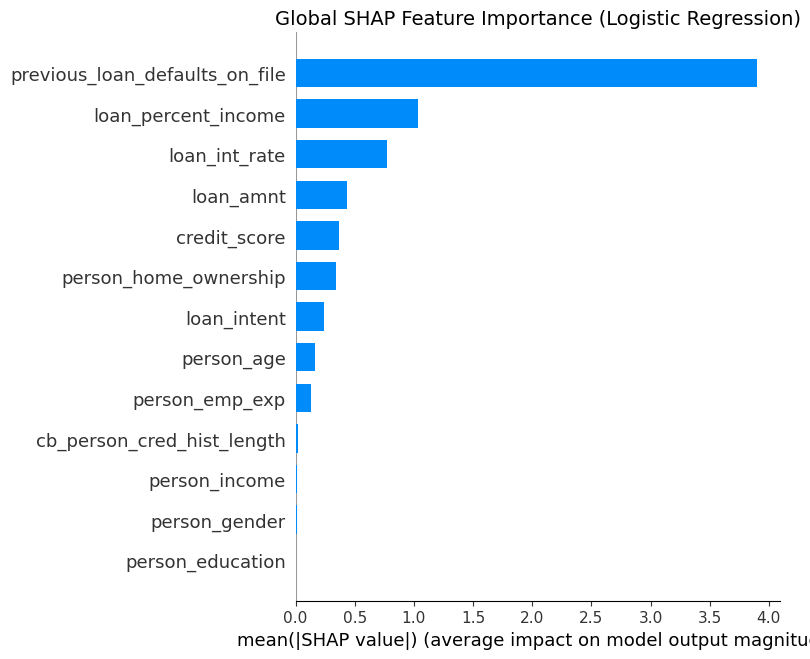

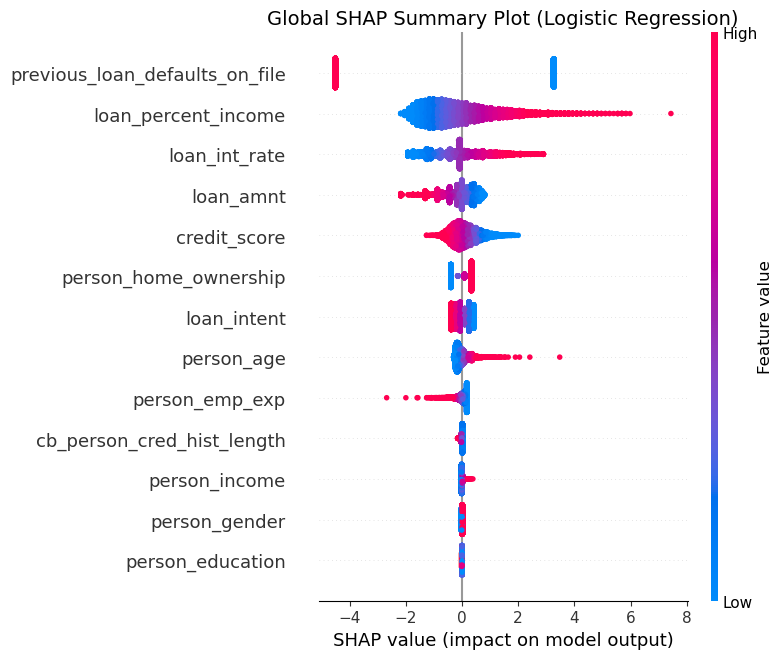

In [ ]:
for name in models:
    for model_name in models[name]:
        if model_name != "Random Forest":
            model = trained_models_data1[model_name]
            X_train_model, _, X_test_model, y_test_model = tools_data1[name]
            if name == "linear":
                explainer = shap.LinearExplainer(model, X_train_model)
            else:
                explainer = shap.TreeExplainer(model)
            shap_values = explainer.shap_values(X_test_model)
        
            plt.figure(figsize=(10, 6))
            plt.title(f"Global SHAP Feature Importance ({model_name})", fontsize=14)
            shap.summary_plot(shap_values, X_test_model, plot_type="bar", show=False)
            plt.show()

            plt.figure(figsize=(10, 6))
            plt.title(f"Global SHAP Summary Plot ({model_name})", fontsize=14)
            shap.summary_plot(shap_values, X_test_model, show=False)
            plt.show()

### PDP/ICE

In [ ]:
for name in models:
    for model_name in models[name]:
        model = trained_models_data1[model_name]
        _, _, X_test_model, _ = tools_data1[name]
        features_to_plot = X_test_model.columns  # Chọn 2 đặc trưng đầu tiên để vẽ PDP/ICE
        fig, ax = plt.subplots(figsize=(12, 6))
        display = PartialDependenceDisplay.from_estimator(
            estimator=model,
            X=X_test_model,
            features=features_to_plot,
            kind="both",       
            subsample=50,
            random_state=42,
            ax=ax
        )
        fig.suptitle(f"Partial Dependence and ICE Plots ({model_name})", fontsize=16)
        fig.tight_layout()
        plt.show()

## Local explanation

### Local explanation with LIME

### Local explanation with SHAP

### Local explanation with DiCE

# Breast cancer diagnosis

In [ ]:
data3 = pd.read_csv("./Datasets/BreastCancer.csv")
data3

In [ ]:
data3.columns

In [ ]:
data3.dtypes

In [ ]:
X = data3.drop(columns=['loan_status'])
y = data3['loan_status']

In [ ]:
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

feature_names = numerical_cols + categorical_cols

In [ ]:
preprocessor_data3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ]
)

X_train_processed = preprocessor_data3.fit_transform(X_train)
X_test_processed = preprocessor_data3.transform(X_test)
X_train_final = pd.DataFrame(X_train_processed, columns=feature_names, index=X_train.index)
X_test_final = pd.DataFrame(X_test_processed, columns=feature_names, index=X_test.index)

In [ ]:
tools_data3 = {
    "linear": (X_train_final, y_train, X_test_final, y_test),
    "tree": (X_train, y_train, X_test, y_test)
}

In [ ]:
results_data3 = []
trained_models_data3 = {}

for name in models:
    for model_name, model in models[name]:
        X_train_model, y_train_model, X_test_model, y_test_model = tools_data3[name]
        model.fit(X_train_model, y_train_model)
        y_pred = model.predict(X_test_model)
        accuracy = accuracy_score(y_test_model, y_pred)
        f1 = f1_score(y_test_model, y_pred)
        roc_auc = roc_auc_score(y_test_model, model.predict_proba(X_test_model)[:, 1])
        results_data3.append({
            "Model": model_name,
            "Accuracy": accuracy,
            "F1 Score": f1,
            "ROC AUC": roc_auc
        })
        trained_models_data3[model_name] = model

performance_df_data3 = pd.DataFrame(results_data3).set_index("Model")
display(performance_df_data3)